<a href="https://colab.research.google.com/github/julietapgomez/Data-Science-III/blob/main/Proyecto_Final_DS_III_Julieta_Gomez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificación automática de sentimiento en reseñas de Amazon mediante NLP y Deep Learning**

## Objetivo

El presente trabajo tiene como objetivo aplicar técnicas de Procesamiento de Lenguaje Natural (NLP) y Deep Learning para clasificar automáticamente el sentimiento de reseñas de productos de Amazon.

Se busca transformar texto en representaciones numéricas mediante técnicas de vectorización y entrenar modelos capaces de predecir si una reseña expresa un sentimiento positivo, neutral o negativo.

Además, se comparará el desempeño de un modelo baseline de Machine Learning clásico (Regresión Logística) frente a modelos basados en redes neuronales, evaluando ventajas, limitaciones y capacidad de generalización.

In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_style("whitegrid")

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
#Carga del dataset
from google.colab import files
uploaded = files.upload()

Saving amazon reviews.csv to amazon reviews.csv


In [4]:
import pandas as pd

df = pd.read_csv("amazon reviews.csv")

df.head()

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


In [5]:
df.columns

Index(['sentiments', 'cleaned_review', 'cleaned_review_length',
       'review_score'],
      dtype='object')

In [8]:
df.shape

(17340, 4)

In [9]:
df.describe(include="all")

,sentiments,cleaned_review,cleaned_review_length,review_score
count,17340,17337,17340.000000,17340.000000
unique,3,13193,NaN,NaN
top,positive,works great,NaN,NaN
freq,9503,45,NaN,NaN
mean,NaN,NaN,30.300461,3.649077
std,NaN,NaN,35.836540,1.673500
min,NaN,NaN,0.000000,1.000000
25%,NaN,NaN,9.000000,2.000000
50%,NaN,NaN,20.000000,5.000000
75%,NaN,NaN,38.000000,5.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17340 non-null  object 
 1   cleaned_review         17337 non-null  object 
 2   cleaned_review_length  17340 non-null  int64  
 3   review_score           17340 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 542.0+ KB


## Exploración inicial del dataset

El dataset contiene reseñas de productos de Amazon junto con su clasificación de sentimiento. Se observa la presencia de variables textuales y numéricas, incluyendo el texto procesado de la reseña, longitud textual y score de valoración.

Durante esta etapa se verificó la estructura general de los datos, cantidad de registros, tipos de variables y posibles valores faltantes.

In [11]:
#Ver desbalance
df["sentiments"].value_counts()

,count
sentiments,
positive,9503
neutral,6303
negative,1534


In [12]:
df["sentiments"].value_counts(normalize=True) * 100

,proportion
sentiments,
positive,54.803922
neutral,36.349481
negative,8.846597


## Distribución de clases

Se observa un desbalance en las clases del dataset, predominando las reseñas positivas (54,8%), seguidas por las neutrales (36,3%) y, en menor proporción, las negativas (8,8%).

Este comportamiento puede influir en el desempeño de los modelos predictivos, favoreciendo una mayor precisión sobre las clases más representadas y dificultando la detección de categorías minoritarias, especialmente las reseñas negativas.

In [13]:
df.isnull().sum()

,0
sentiments,0
cleaned_review,3
cleaned_review_length,0
review_score,0


In [14]:
df = df.dropna()

In [15]:
df.isnull().sum()

,0
sentiments,0
cleaned_review,0
cleaned_review_length,0
review_score,0


Se observa una distribución desbalanceada de clases, predominando las reseñas positivas, seguidas por las neutrales y, en menor medida, las negativas. Este comportamiento podría influir en el desempeño de los modelos predictivos, favoreciendo una mayor precisión sobre las clases más representadas

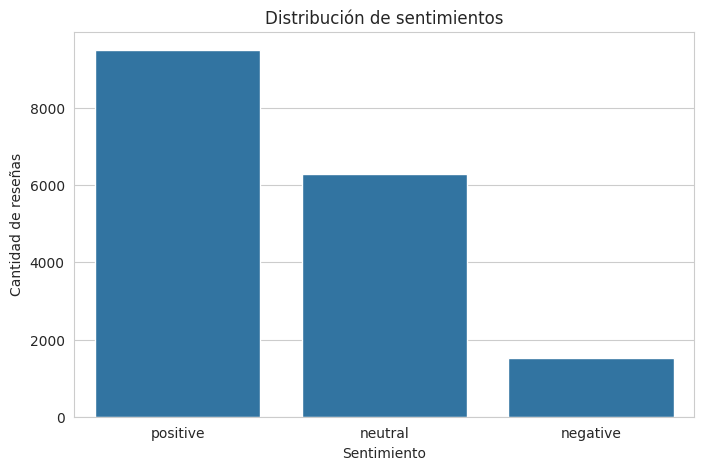

In [16]:
#Visualizacion de Clases
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sentiments"
)

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")

plt.show()

In [17]:
df["review_length"] = df["cleaned_review"].astype(str).apply(len)

In [18]:
df["review_length"].describe()

,review_length
count,17337.000000
mean,161.011882
std,191.123876
min,1.000000
25%,48.000000
50%,104.000000
75%,204.000000
max,3252.000000


## Análisis de longitud textual

La longitud de las reseñas presenta una distribución asimétrica positiva (sesgada hacia la derecha), observándose una alta concentración de textos cortos y medianos, junto con algunos casos extremos de reseñas muy extensas.

Esto sugiere que la mayoría de los usuarios expresan opiniones relativamente breves, aunque ciertos casos contienen explicaciones mucho más detalladas.

---



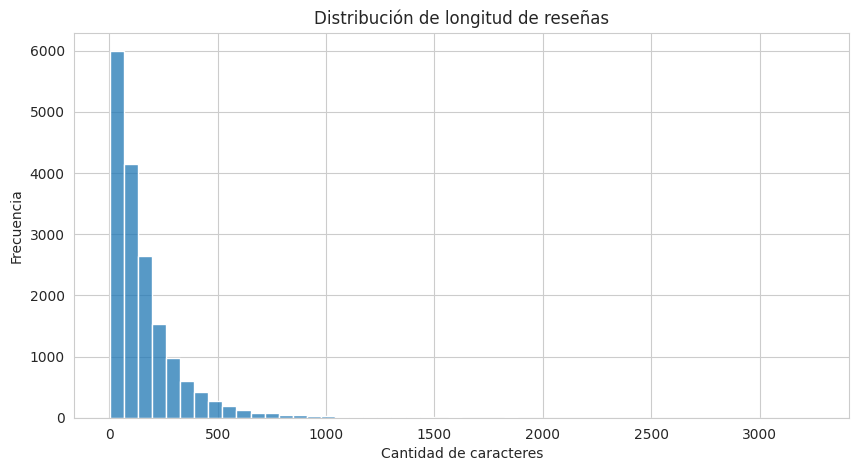

In [19]:
#Histograma de Distribución de longitud de reseñas
plt.figure(figsize=(10,5))

sns.histplot(
    df["review_length"],
    bins=50
)

plt.title("Distribución de longitud de reseñas")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.show()

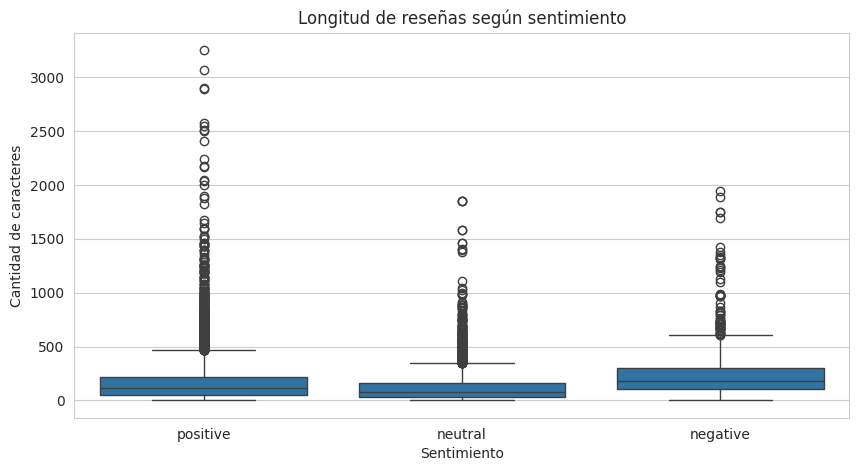

In [20]:
#Longitud por sentimiento
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="sentiments",
    y="review_length"
)

plt.title("Longitud de reseñas según sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de caracteres")

plt.show()

## Longitud textual según sentimiento

Se observa que las reseñas negativas presentan, en promedio, una mayor longitud textual respecto de las neutrales y positivas.

Esto podría sugerir que los usuarios insatisfechos tienden a brindar explicaciones más detalladas de su experiencia, mientras que las reseñas positivas suelen expresarse de manera más breve y directa.

In [21]:
df.groupby("sentiments")["review_length"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiments,,,,,,,,
negative,1534.0,235.078227,211.397362,3.0,102.0,175.0,303.0,1944.0
neutral,6300.0,120.925397,136.456292,1.0,35.0,81.0,160.0,1852.0
positive,9503.0,175.631169,211.957812,4.0,52.0,111.0,218.0,3252.0


In [22]:
df["cleaned_review"].sample(10, random_state=42)

,cleaned_review
14785,it meets my need
14534,i shopped around for while great speaker sound...
16246,why there no lights or showing if it charged o...
6385,it had connectivity issues right out of the bo...
424,don buy it for one is very inconvenient rechar...
12243,you get what you pay for hold true with this p...
7657,love this mouse mouse came days before deliver...
4610,the mouse is not effective charged for hours s...
7578,worked great for about week now won work love ...
10405,no complaints


In [23]:
#Aplicación de NLTK
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [24]:
#importación de herrmaientas
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [25]:
#stopwords
stop_words = set(stopwords.words("english"))

In [26]:
#Inicializar lematizador
lemmatizer = WordNetLemmatizer()

In [27]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Procesamiento de Lenguaje Natural (NLP)

Con el objetivo de preparar el texto para el modelado predictivo, se aplicó un pipeline de preprocesamiento NLP sobre las reseñas.

Las etapas incluyeron:

- Conversión a minúsculas
- Tokenización
- Eliminación de stopwords
- Filtrado de palabras no alfabéticas
- Lematización

El objetivo de estas transformaciones es reducir ruido textual y conservar información relevante para el proceso de clasificación.

In [28]:
#Creación de función preprocessing
def preprocess_text(text):

    # Convertir a string
    text = str(text)

    # Minúsculas
    text = text.lower()

    # Tokenización
    tokens = word_tokenize(text)

    # Eliminar stopwords y palabras no alfabéticas
    filtered_tokens = [
        word for word in tokens
        if word.isalpha()
        and word not in stop_words
    ]

    # Lematización
    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in filtered_tokens
    ]

    return " ".join(lemmatized_tokens)

In [58]:
df[
    ["cleaned_review", "processed_review"]
].head(10)

,cleaned_review,processed_review
0,i wish would have gotten one earlier love it a...,wish would gotten one earlier love make workin...
1,i ve learned this lesson again open the packag...,learned lesson open package use product right ...
2,it is so slow and lags find better option,slow lag find better option
3,roller ball stopped working within months of m...,roller ball stopped working within month minim...
4,i like the color and size but it few days out ...,like color size day return period hold charge
5,overall love this mouse the size weight clicki...,overall love mouse size weight clicking fabulo...
6,it stopped working,stopped working
7,my son uses school issued chromebook for schoo...,son us school issued chromebook school work ha...
8,loved this cute little mouse but it broke afte...,loved cute little mouse broke month wheel brok...
9,should ve spent the money to get quality produ...,spent money get quality product thing stopped ...


In [30]:
df = df.dropna(subset=["cleaned_review"]).copy()

In [31]:
df["processed_review"] = df["cleaned_review"].apply(preprocess_text)

In [32]:
df[["cleaned_review", "processed_review"]].sample(10, random_state=42)

,cleaned_review,processed_review
14785,it meets my need,meet need
14534,i shopped around for while great speaker sound...,shopped around great speaker sound excellent h...
16246,why there no lights or showing if it charged o...,light showing charged turn see light see charg...
6385,it had connectivity issues right out of the bo...,connectivity issue right box contacted seller ...
424,don buy it for one is very inconvenient rechar...,buy one inconvenient rechargeable never know m...
12243,you get what you pay for hold true with this p...,get pay hold true product senior citizen fixed...
7657,love this mouse mouse came days before deliver...,love mouse mouse came day delivery eta always ...
4610,the mouse is not effective charged for hours s...,mouse effective charged hour still life functi...
7578,worked great for about week now won work love ...,worked great week work love color quiet click ...
10405,no complaints,complaint


In [33]:
df["processed_review"].isnull().sum()

np.int64(0)

Se observa cómo el texto original es simplificado eliminando palabras poco informativas y reduciendo variaciones lingüísticas a una forma base (lematización), conservando principalmente términos con contenido semántico relevante.

In [35]:
#convertir texto en números con TF-IDF.

#Separar variables: X es el texto procesado e y es lo que quiero predecir.

X = df["processed_review"]
y = df["sentiments"]

In [36]:
#Separar entrenamiento y test

#Uso stratify=y porque el dataset está desbalanceado. Así mantengo proporciones similares de positivos, neutrales y negativos en train y test.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Vectorización del texto

Los algoritmos de Machine Learning y Deep Learning no pueden procesar texto directamente, por lo que fue necesario convertir las reseñas en representaciones numéricas.

Para ello se utilizó TF-IDF (Term Frequency - Inverse Document Frequency), técnica que pondera la importancia de cada palabra considerando tanto su frecuencia en una reseña como su rareza en el conjunto total de documentos.

In [37]:
#Vectorizar con TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


#Aclaración
#max_features=5000 limita el vocabulario a las 5000 palabras/frases más relevantes.
#ngram_range=(1,2) considera palabras individuales y pares de palabra

In [38]:
#Ver la forma de la matriz

#filas = reseñas
#columnas = términos TF-IDF

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(13869, 5000)
(3468, 5000)


Se utilizó TF-IDF para transformar las reseñas procesadas en una matriz numérica.

La configuración incluyó:

- `max_features=5000`: limita el vocabulario a los términos más relevantes.
- `ngram_range=(1,2)`: incorpora unigramas y bigramas, permitiendo capturar tanto palabras individuales como combinaciones frecuentes.

Esto permite representar el lenguaje en formato numérico preservando parte de la estructura textual.

## **Aplicación del primer modelo baseline: Regresión Logística**


Antes de implementar modelos de Deep Learning, se entrenó un modelo baseline basado en Regresión Logística.

Este algoritmo es ampliamente utilizado en clasificación textual debido a su interpretabilidad, rapidez y buen desempeño sobre representaciones TF-IDF, permitiendo establecer un punto de comparación inicial.

In [39]:
from sklearn.linear_model import LogisticRegression

# Crear modelo
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenar
log_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

El modelo baseline fue entrenado sobre la representación TF-IDF con el objetivo de aprender patrones lingüísticos asociados a cada categoría de sentimiento (positivo, neutral y negativo).

In [40]:
#Predicciones

y_pred = log_model.predict(X_test_tfidf)

In [41]:
#Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8356401384083045


Si bien el modelo tiene un accuracy bastante elevado, el dataset está desbalanceado debido a que tiene muchos reviews positivos, por lo que se necesitan otras métricas de clasificación

In [42]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.77      0.33      0.46       307
     neutral       0.77      0.84      0.80      1260
    positive       0.89      0.92      0.90      1901

    accuracy                           0.84      3468
   macro avg       0.81      0.69      0.72      3468
weighted avg       0.83      0.84      0.83      3468



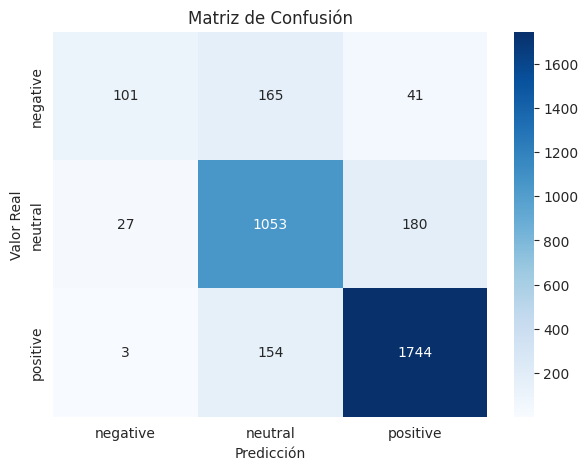

In [43]:
#Matriz de confusión

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_model.classes_,
    yticklabels=log_model.classes_
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

El modelo baseline alcanzó un accuracy aproximado del 83,5%, mostrando un desempeño sólido en la clasificación de reseñas positivas y neutrales.

Sin embargo, se observó una baja capacidad para identificar reseñas negativas reales, reflejada en un recall reducido para esta clase.

Esto podría explicarse tanto por el desbalance presente en el dataset como por las limitaciones de TF-IDF para capturar contexto, ironías o negaciones complejas del lenguaje.

## **Deep Learning**

# Modelo 1



Con el objetivo de evaluar posibles mejoras respecto del baseline, se implementaron modelos de Deep Learning utilizando redes neuronales densas.

El propósito es analizar si arquitecturas más complejas logran capturar patrones lingüísticos adicionales presentes en las reseñas.

In [44]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder

In [45]:
#Conversión de clases a números

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [46]:
#Creación Modelo 1
model_1 = Sequential([
    Dense(
        64,
        activation='relu',
        input_shape=(X_train_tfidf.shape[1],)
    ),

    Dense(
        3,
        activation='softmax'
    )
])

In [47]:
#Compilar

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
#Resumen del modelo

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,259 (1.22 MB)

 Trainable params: 320,259 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
#Entrenar el modelo

history_1 = model_1.fit(
    X_train_tfidf.toarray(),
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7020 - loss: 0.6957 - val_accuracy: 0.7797 - val_loss: 0.5293
Epoch 2/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8549 - loss: 0.3816 - val_accuracy: 0.8176 - val_loss: 0.4471
Epoch 3/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9156 - loss: 0.2549 - val_accuracy: 0.8309 - val_loss: 0.4460
Epoch 4/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9443 - loss: 0.1831 - val_accuracy: 0.8360 - val_loss: 0.4621
Epoch 5/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9631 - loss: 0.1358 - val_accuracy: 0.8381 - val_loss: 0.5006
Epoch 6/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9760 - loss: 0.1022 - val_accuracy: 0.8335 - val_loss: 0.5327
Epoch 7/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9838 - loss: 0.0784 - val_accuracy: 0.8367 - val_loss: 0.5799
Epoch 8/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9886 - loss: 0.0596 - val_accuracy: 0.

El Modelo 1 consistió en una red neuronal simple con una capa oculta de 64 neuronas y función de activación ReLU.

Este modelo alcanzó un accuracy cercano al baseline de Regresión Logística, aunque se observó cierta diferencia entre accuracy de entrenamiento y validación, sugiriendo posible overfitting moderado.

Por este motivo, se decidió experimentar con una arquitectura más robusta incorporando regularización.

## Modelo 2

In [50]:
from tensorflow.keras.layers import Dropout

model_2 = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(X_train_tfidf.shape[1],)
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        3,
        activation='softmax'
    )
])

In [51]:
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history_2 = model_2.fit(
    X_train_tfidf.toarray(),
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7054 - loss: 0.6637 - val_accuracy: 0.7920 - val_loss: 0.4979
Epoch 2/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8549 - loss: 0.3676 - val_accuracy: 0.8262 - val_loss: 0.4363
Epoch 3/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9219 - loss: 0.2220 - val_accuracy: 0.8288 - val_loss: 0.4610
Epoch 4/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9566 - loss: 0.1357 - val_accuracy: 0.8378 - val_loss: 0.5202
Epoch 5/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9775 - loss: 0.0815 - val_accuracy: 0.8407 - val_loss: 0.6082
Epoch 6/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9858 - loss: 0.0528 - val_accuracy: 0.8356 - val_loss: 0.6817
Epoch 7/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9913 - loss: 0.0338 - val_accuracy: 0.8396 - val_loss: 0.7453
Epoch 8/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9938 - loss: 0.0237 - val_accuracy: 0.

A pesar de incorporar una segunda capa oculta y regularización mediante Dropout, no se observaron mejoras drásticas en accuracy global, aunque sí se identificaron mejoras relevantes en la detección de la clase negativa, especialmente en recall.

Sin embargo, se decidió evaluar el desempeño sobre el conjunto de test para analizar si existían mejoras específicas en la detección de clases minoritarias.

# Evaluación del Modelo 2 en test

In [53]:
test_loss, test_accuracy = model_2.evaluate(
    X_test_tfidf.toarray(),
    y_test_encoded
)

print("Test Accuracy:", test_accuracy)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8478 - loss: 0.8100
Test Accuracy: 0.8477508425712585


In [54]:
#Predicciones

y_pred_dl = model_2.predict(
    X_test_tfidf.toarray()
)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [55]:
#Conversión de probabilidades a clases

import numpy as np

y_pred_dl_classes = np.argmax(
    y_pred_dl,
    axis=1
)

In [56]:
#Classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_pred_dl_classes,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    negative       0.72      0.59      0.65       307
     neutral       0.80      0.82      0.81      1260
    positive       0.90      0.91      0.90      1901

    accuracy                           0.85      3468
   macro avg       0.81      0.77      0.79      3468
weighted avg       0.85      0.85      0.85      3468



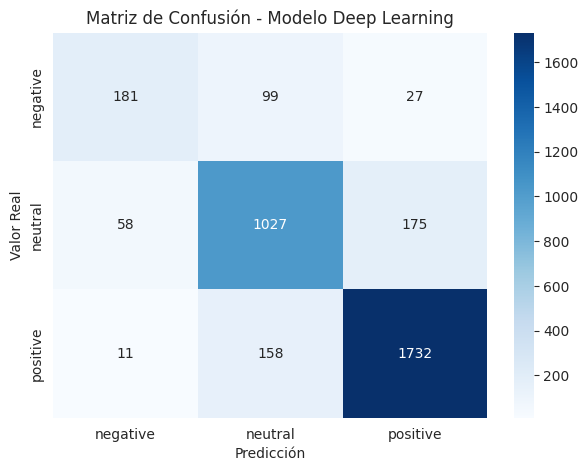

In [57]:
#Matriz de confusión

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dl = confusion_matrix(
    y_test_encoded,
    y_pred_dl_classes
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_dl,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de Confusión - Modelo Deep Learning")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

# **Conclusión final**

El presente trabajo permitió aplicar técnicas de Procesamiento de Lenguaje Natural (NLP) y Deep Learning sobre un dataset real de reseñas de Amazon, con el objetivo de clasificar automáticamente el sentimiento de los usuarios.

En una primera instancia, se aplicó un pipeline de preprocesamiento textual compuesto por tokenización, eliminación de stopwords y lematización, seguido de una representación TF-IDF para convertir texto en variables numéricas.

Como baseline se utilizó Regresión Logística, obteniendo un desempeño sólido cercano al 83,5% de accuracy. Posteriormente, se implementaron dos arquitecturas de Deep Learning utilizando redes neuronales densas.

El segundo modelo alcanzó aproximadamente un 84,8% de accuracy, evidenciando una mejora moderada respecto del baseline. No obstante, el incremento global en rendimiento fue limitado, lo que sugiere que para problemas de clasificación textual representados mediante TF-IDF, los modelos clásicos continúan siendo altamente competitivos.

Sin embargo, se observó una mejora importante en la detección de reseñas negativas, particularmente en recall de la clase minoritaria, aspecto relevante considerando el desbalance presente en el dataset.

Como trabajo futuro, podrían explorarse embeddings semánticos (Word2Vec, GloVe o FastText) y arquitecturas recurrentes o transformers capaces de capturar mejor el contexto del lenguaje.